# 🌪️ Disaster Tweet Classification Project

Welcome to the project! In this notebook, our goal is to build a machine learning model capable of analyzing a tweet and predicting whether it is about a real-world disaster or just regular conversation.

### Step 1: Data Exploration and Preparation
First, we will load our dataset, visualize the distribution of our target labels, and clean our text data so our model can understand it easily.

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


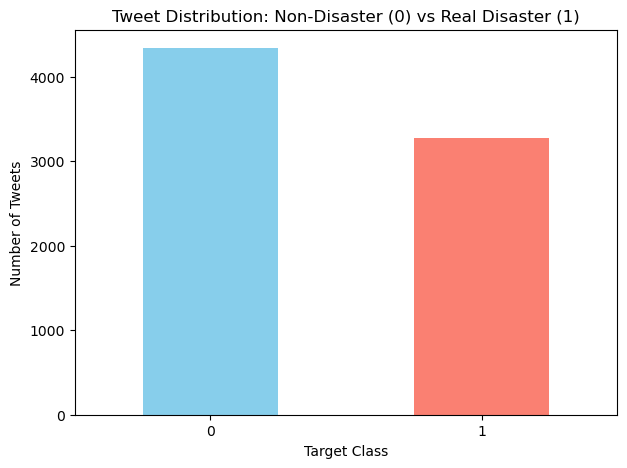

Data split successfully! Training samples: 6090 | Testing samples: 1523


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv('twitter_disaster (1).csv')

# Let's take a quick look at the first few rows
display(df.head())

# 2. Visualize the data distribution
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], figsize=(7, 5))
plt.title('Tweet Distribution: Non-Disaster (0) vs Real Disaster (1)')
plt.xlabel('Target Class')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()

# 3. Clean the text data
def clean_text(tweet):
    tweet = str(tweet)
    tweet = re.sub(r'http\S+', '', tweet)  # Remove URLs
    tweet = re.sub(r'[^A-Za-z0-9 ]+', '', tweet)  # Remove special characters and punctuation
    return tweet.lower()  # Convert to lowercase

df['cleaned_text'] = df['text'].apply(clean_text)

# 4. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['target'], test_size=0.2, random_state=42
)

print(f"Data split successfully! Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

---
### Step 2: Feature Engineering and Model Training
Machine learning models cannot read raw text; they need numbers. We will use a `TfidfVectorizer` to convert our cleaned words into numerical scores based on their importance. Then, we will train a Logistic Regression model to classify the tweets.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer on the training data and transform both train and test sets
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Feature engineering complete. Text has been converted to numerical vectors.")

# 2. Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Model training complete!")

# 3. Make predictions on our unseen test set to check initial accuracy
predictions = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, predictions)

print(f"Initial Model Accuracy: {accuracy * 100:.2f}%")

Feature engineering complete. Text has been converted to numerical vectors.
Model training complete!
Initial Model Accuracy: 80.70%


---
### Step 3: Model Evaluation
Accuracy alone doesn't tell the whole story. We need to look at precision, recall, and how often the model gets "confused" between real and fake disasters. Let's visualize its performance using a Confusion Matrix and an ROC Curve.


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       874
           1       0.82      0.70      0.76       649

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523



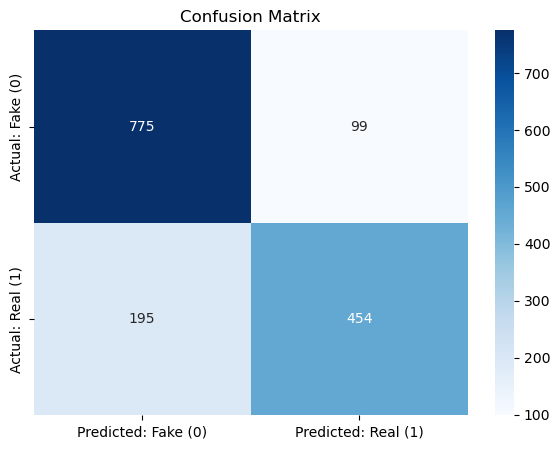


--- ROC CURVE ---


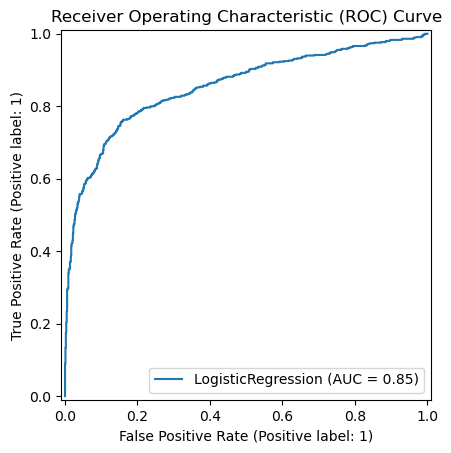

In [3]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

# 1. Print the detailed classification report
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, predictions))

# 2. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Fake (0)', 'Predicted: Real (1)'], 
            yticklabels=['Actual: Fake (0)', 'Actual: Real (1)'])
plt.title('Confusion Matrix')
plt.show()

# 3. Plot the ROC Curve to evaluate model performance
print("\n--- ROC CURVE ---")
RocCurveDisplay.from_estimator(model, X_test_vec, y_test)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

---
### Step 4: Model Serialization (Saving for Deployment)
Now that our model is fully trained and evaluated, we need to save it so it can be integrated into a web application. We will export both the model (the "brain") and the vectorizer (the "translator") as `.pkl` files.

In [4]:
import pickle

# Save the trained model
with open('disaster_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# Save the TF-IDF vectorizer
with open('vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(vectorizer, vec_file)

print(" Success! 'disaster_model.pkl' and 'vectorizer.pkl' have been saved successfully.")
print("You can now download these files from the folder panel on the left to use in your web application.")

 Success! 'disaster_model.pkl' and 'vectorizer.pkl' have been saved successfully.
You can now download these files from the folder panel on the left to use in your web application.
